In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

import copy
from torch.utils.data import DataLoader, TensorDataset

from models import *

In [2]:
class Generator2D:
    def __init__(self, f, matrix_transform, noise_type='gaussian', noise_std=1.0):
        self.f = f
        self.matrix_transform = matrix_transform
        self.noise_type = noise_type
        self.noise_std = noise_std

    def _get_noise(self, n):
        if self.noise_type == 'gaussian':
            noise = torch.randn(n, 2)
        elif self.noise_type == 'uniform':
            noise = torch.rand(n, 2) * 2 - 1
        elif self.noise_type == 'exponential':
            noise = torch.distributions.Exponential(rate=1.0).sample((n, 2))
        else:
            raise ValueError(f"Type inconnu: {self.noise_type}")
        return (noise * self.noise_std).unsqueeze(2)

    def generate(self, n):
        x = 2 * torch.rand(n, 1) - 1
        fx = self.f(x)
        A_x = self.matrix_transform(x)
        noise = self._get_noise(n)
        correlated_noise = torch.bmm(A_x, noise).squeeze(2)
        y = fx + correlated_noise
        return x, y

    def generate_specific_y_given_x(self, x_tensor, n=1):
        x_repeated = x_tensor.repeat_interleave(n, dim=0)
        fx = self.f(x_repeated)
        A_x = self.matrix_transform(x_repeated)
        noise = self._get_noise(x_repeated.shape[0])
        correlated_noise = torch.bmm(A_x, noise).squeeze(2)
        y_flat = fx + correlated_noise
        return y_flat.view(n, 2)

def strange_matrix_transform(x):
    n = x.shape[0]
    matrices = torch.eye(2).unsqueeze(0).repeat(n, 1, 1)
    matrices[:, 0, 0] = x.squeeze(-1)**2 + 0.5 
    matrices[:, 0, 1] = torch.sin(x.squeeze(-1) * 2)
    matrices[:, 1, 1] = torch.abs(x.squeeze(-1)) + 0.2
    return matrices

def circle_f(x):
    return torch.cat([torch.sin(x*3), torch.cos(x*3)], dim=1)



def plot_samples_with_contours_multi_flow(data_generator, model, tau=0.9, x_range=(-1, 1), num_slices=8, n_samples=200):
    model.eval()

    fig = plt.figure(figsize=(12, 9), dpi=120)
    ax = fig.add_subplot(111, projection='3d')

    xs = np.linspace(x_range[0], x_range[1], num_slices)

    for x_val in xs:

        x_tensor = torch.tensor([[x_val]], dtype=torch.float32)
        samples = data_generator.generate_specific_y_given_x(x_tensor, n=n_samples)
        samples_np = samples.numpy()

        y1_min, y1_max = samples[:, 0].min().item() - 1, samples[:, 0].max().item() + 1
        y2_min, y2_max = samples[:, 1].min().item() - 1, samples[:, 1].max().item() + 1

        y1_grid_vals = np.linspace(y1_min, y1_max, 100)
        y2_grid_vals = np.linspace(y2_min, y2_max, 100)

        Y1, Y2 = np.meshgrid(y1_grid_vals, y2_grid_vals)

        y1_tensor = torch.tensor(Y1.flatten(), dtype=torch.float32)
        y2_tensor = torch.tensor(Y2.flatten(), dtype=torch.float32)

        Y_grid = torch.stack([y1_tensor, y2_tensor], dim=1)

        x_scatter = np.full(n_samples, x_val)

        ax.scatter(
            x_scatter,
            samples_np[:, 0],
            samples_np[:, 1],
            c="grey",
            s=8,
            alpha=0.5,
            zorder=1
        )

        with torch.no_grad():
            # --- NOUVEAU : Récupération du seuil calibré q_val ---
            # Optimisation: on le calcule sur x_tensor (1 point) au lieu de X_grid (10 000 points)
            conformalize_out = model.call_conformalize(x_tensor)
            q_val = conformalize_out[-1][0, 0].item()

            # --- NOUVEAU : Calcul des scores de la grille en 2 lignes ---
            X_grid = x_tensor.repeat(Y_grid.shape[0], 1)
            S_grid_raw, _, _ = model.get_frontiers(X_grid, Y_grid)
            
            # On redimensionne directement le score brut pour l'affichage
            S_grid_2d = S_grid_raw.reshape(Y1.shape).numpy()

        if S_grid_2d.min() <= q_val <= S_grid_2d.max():

            fig_dummy, ax_dummy = plt.subplots()

            cs = ax_dummy.contour(Y1, Y2, S_grid_2d, levels=[q_val])

            paths = cs.collections[0].get_paths() if hasattr(cs, 'collections') else cs.get_paths()

            for path in paths:

                vertices = path.vertices

                x_line = np.full(vertices.shape[0], x_val)
                y1_line = vertices[:, 0]
                y2_line = vertices[:, 1]

                ax.plot(
                    x_line,
                    y1_line,
                    y2_line,
                    color='red',
                    linewidth=2.5,
                    zorder=10
                )

            plt.close(fig_dummy)

        else:
            print(f"Attention: quantile {q_val:.2f} hors grille pour x={x_val:.2f}")

    ax.set_xlabel('X', fontsize=18, labelpad=10)
    ax.set_ylabel('Y1', fontsize=18, labelpad=10)
    ax.set_zlabel('Y2', fontsize=18, labelpad=10)

    ax.set_xlim(x_range[0], x_range[1])
    ax.set_ylim(-4, 4)
    ax.set_zlim(-2, 6)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.view_init(elev=20, azim=-67)

    plt.tight_layout()
    plt.title(f"Régions de confiance conditionnelles {tau*100:.0f}%")
    plt.show()



Epoch 10/1000 | T-Loss: -0.9255 | T-Cov: 0.937 | T-Vol: 21.1452 | BEST-Vol: 21.1452 | tau_low: 0.45 | tau_high: 1.00 | T-pb-loss: 1.39 
Epoch 20/1000 | T-Loss: -0.9893 | T-Cov: 0.944 | T-Vol: 18.7172 | BEST-Vol: 17.6448 | tau_low: 0.45 | tau_high: 1.00 | T-pb-loss: 1.16 
Epoch 30/1000 | T-Loss: -1.0147 | T-Cov: 0.947 | T-Vol: 17.4317 | BEST-Vol: 17.1651 | tau_low: 0.45 | tau_high: 1.00 | T-pb-loss: 1.10 
Epoch 40/1000 | T-Loss: -1.0309 | T-Cov: 0.943 | T-Vol: 16.7127 | BEST-Vol: 16.1333 | tau_low: 0.45 | tau_high: 1.00 | T-pb-loss: 1.10 
Epoch 50/1000 | T-Loss: 0.0158 | T-Cov: 0.952 | T-Vol: 13.6973 | BEST-Vol: 13.6973 | tau_low: 0.47 | tau_high: 0.99 | T-pb-loss: 1.37 
Epoch 60/1000 | T-Loss: -0.0234 | T-Cov: 0.954 | T-Vol: 13.6040 | BEST-Vol: 13.5393 | tau_low: 0.50 | tau_high: 0.97 | T-pb-loss: 1.55 
Epoch 70/1000 | T-Loss: -0.0285 | T-Cov: 0.956 | T-Vol: 12.6944 | BEST-Vol: 12.6944 | tau_low: 0.53 | tau_high: 0.96 | T-pb-loss: 1.58 
Epoch 80/1000 | T-Loss: -0.0163 | T-Cov: 0.952 | 

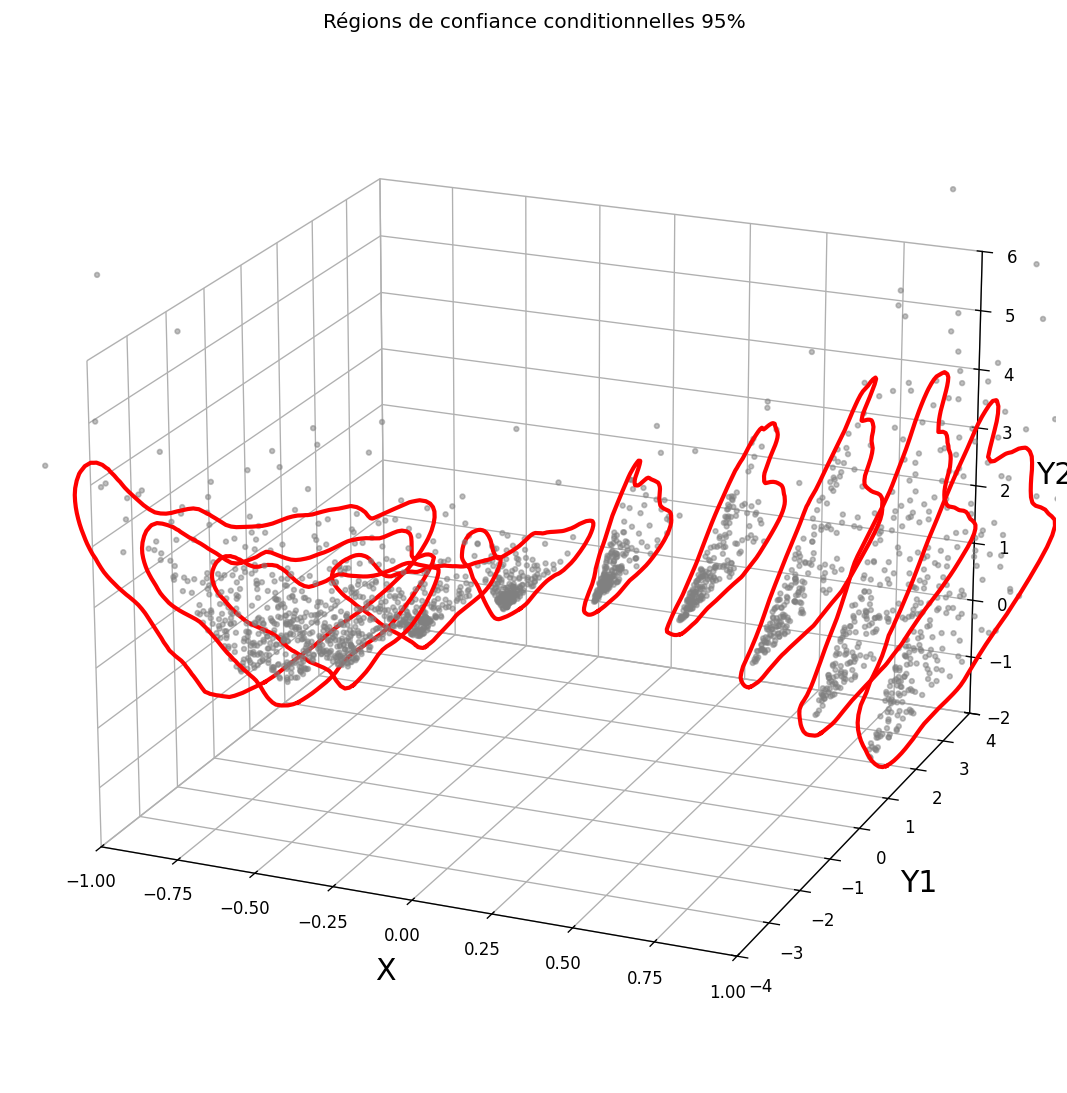

In [3]:
torch.manual_seed(42)

generator = Generator2D(
    f=circle_f,
    matrix_transform=strange_matrix_transform,
    noise_std=1.0,
    noise_type="exponential"
)

# On génère un dataset d'entraînement
N_train = 3000
X_train, Y_train = generator.generate(N_train)
X_calibration, Y_calibration = generator.generate(N_train)
X_test, Y_test = generator.generate(N_train)

dim_X = 1
dim_y = 2

tau = 0.95

batch_size = 256
num_epochs = 1_000
lr = 5e-4

tau_param = TauParameterAnnealer(tau,                
                 warm_start_step=500, 
                 tau_low_target_step=100, 
                 tau_low_steepness=1e-3,
                 tau_high_target_step=100, 
                 tau_high_steepness=1e-2,
                 low_error_init=0.5,   
                 low_error_max=0.01,    
                 high_error_init=0.2,  
                 high_error_max=0.01,  
                 eps=1e-5              
                 )

model = SLS_regressor(dim_X=dim_X, dim_y=dim_y, 
                                    cov_mode="full_cholesky", num_flow_layers=3, K=1,
                                    det_normalized=True
                                    )


model.fit(X_train, Y_train, 
          tau=tau, 
          epochs=num_epochs, 
          lr=lr, 
          batch_size=batch_size, 
          return_best=True, 
          print_every=100,
          tau_parameterAnnealer=tau_param,
          loss_function="log_volume"
          )

model.conformalize(X_calibration, Y_calibration, tau)
vol = model.compute_average_volume(X_test)
print(f"Average volume of the confidence sets: {vol.item():.4f}")

plot_samples_with_contours_multi_flow(generator, model, tau=tau, num_slices=10)